Using device: cpu


100%|██████████| 26.4M/26.4M [00:01<00:00, 17.0MB/s]


Extracting ./data/FashionMNIST/raw/train-images-idx3-ubyte.gz to ./data/FashionMNIST/raw



100%|██████████| 29.5k/29.5k [00:00<00:00, 271kB/s]


Extracting ./data/FashionMNIST/raw/train-labels-idx1-ubyte.gz to ./data/FashionMNIST/raw



100%|██████████| 4.42M/4.42M [00:00<00:00, 5.07MB/s]


Extracting ./data/FashionMNIST/raw/t10k-images-idx3-ubyte.gz to ./data/FashionMNIST/raw



100%|██████████| 5.15k/5.15k [00:00<00:00, 17.5MB/s]


Extracting ./data/FashionMNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/FashionMNIST/raw

Epoch [1/10], Step [200/469], D Loss: 1.2304, G Loss: 1.7172
Epoch [1/10], Step [400/469], D Loss: 1.1449, G Loss: 4.3187


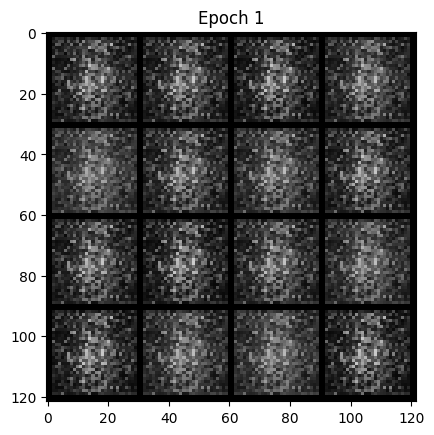

Epoch [2/10], Step [200/469], D Loss: 0.4774, G Loss: 3.9188
Epoch [2/10], Step [400/469], D Loss: 0.4165, G Loss: 2.9681


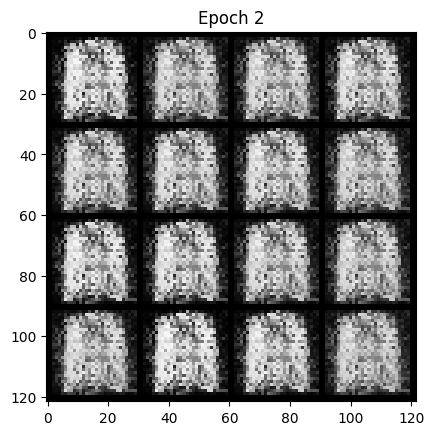

Epoch [3/10], Step [200/469], D Loss: 0.5980, G Loss: 3.2127
Epoch [3/10], Step [400/469], D Loss: 0.5370, G Loss: 2.2402


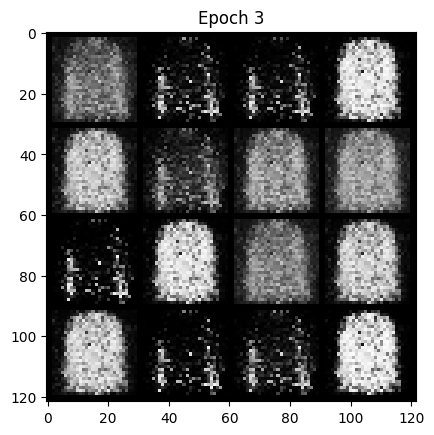

Epoch [4/10], Step [200/469], D Loss: 0.6096, G Loss: 1.7505
Epoch [4/10], Step [400/469], D Loss: 0.4977, G Loss: 2.4683


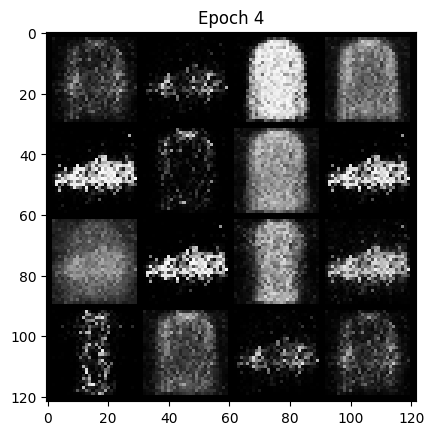

Epoch [5/10], Step [200/469], D Loss: 0.4398, G Loss: 2.2139
Epoch [5/10], Step [400/469], D Loss: 0.8165, G Loss: 1.7334


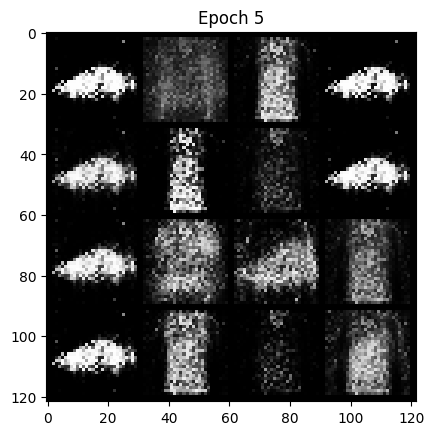

Epoch [6/10], Step [200/469], D Loss: 0.5936, G Loss: 2.5185
Epoch [6/10], Step [400/469], D Loss: 0.5395, G Loss: 1.6591


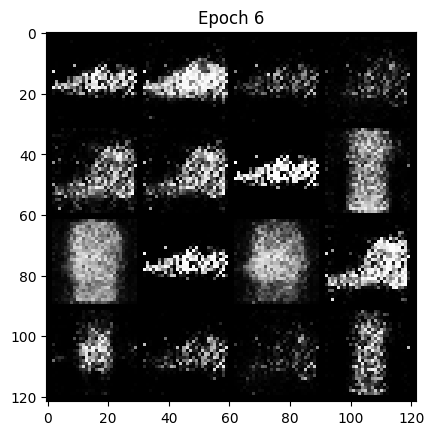

Epoch [7/10], Step [200/469], D Loss: 0.6728, G Loss: 1.6230
Epoch [7/10], Step [400/469], D Loss: 0.7695, G Loss: 1.5260


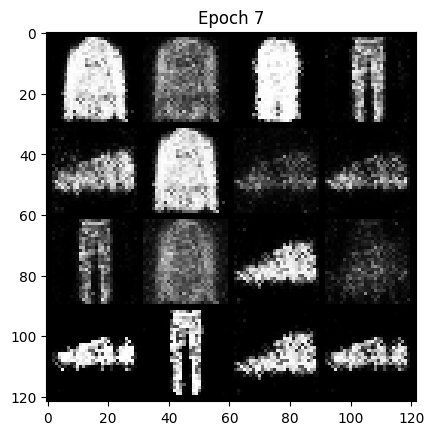

Epoch [8/10], Step [200/469], D Loss: 1.1590, G Loss: 2.7728
Epoch [8/10], Step [400/469], D Loss: 0.8360, G Loss: 1.4850


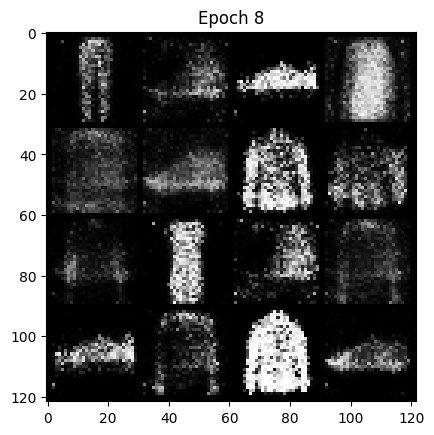

Epoch [9/10], Step [200/469], D Loss: 0.7897, G Loss: 2.0136
Epoch [9/10], Step [400/469], D Loss: 0.7997, G Loss: 1.9328


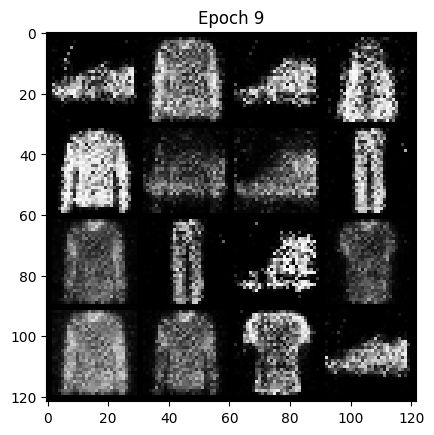

Epoch [10/10], Step [200/469], D Loss: 0.7279, G Loss: 1.7160
Epoch [10/10], Step [400/469], D Loss: 0.9572, G Loss: 1.7984


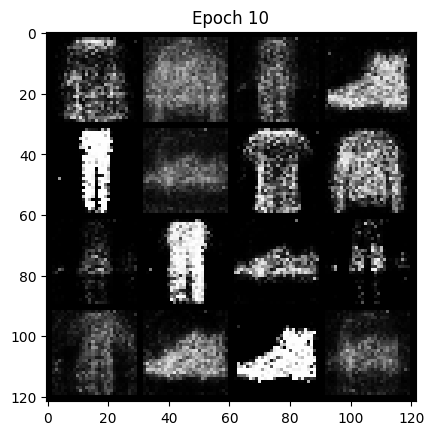

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import torchvision

torch.use_deterministic_algorithms(False)

# 하이퍼파라미터 설정
latent_dim = 100
batch_size = 128
epochs = 10
lr = 0.0002
beta1 = 0.5

# GPU 사용 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# MNIST 데이터 로드
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

fashion_mnist_data = datasets.FashionMNIST(root='./data', train=True, transform=transform, download=True)
data_loader = DataLoader(fashion_mnist_data, batch_size=batch_size, shuffle=True)


# Generator 정의
class Generator(nn.Module):
    def __init__(self, latent_dim):
        super(Generator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(True),
            nn.Linear(256, 512),
            nn.ReLU(True),
            nn.Linear(512, 1024),
            nn.ReLU(True),
            nn.Linear(1024, 28 * 28),
            nn.Tanh()
        )

    def forward(self, z):
        out = self.model(z)
        return out.view(out.size(0), 1, 28, 28)

# Discriminator 정의
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(28 * 28, 1024),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(1024, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = x.view(x.size(0), -1)  # Flatten the input image
        return self.model(x)

# 모델 초기화
generator = Generator(latent_dim).to(device)
discriminator = Discriminator().to(device)

# 손실 함수 및 최적화기 정의
criterion = nn.BCELoss()
optimizer_G = optim.Adam(generator.parameters(), lr=lr, betas=(beta1, 0.999))
optimizer_D = optim.Adam(discriminator.parameters(), lr=lr, betas=(beta1, 0.999))

# 학습 루프
for epoch in range(epochs):
    for i, (real_images, _) in enumerate(data_loader):
        real_images = real_images.to(device)
        batch_size = real_images.size(0)

        # 진짜와 가짜 레이블 생성
        real_labels = torch.ones(batch_size, 1).to(device)
        fake_labels = torch.zeros(batch_size, 1).to(device)

        # **1. Discriminator 학습**
        optimizer_D.zero_grad()

        # 진짜 이미지에 대한 손실
        #print(f"Real images shape: {real_images.shape}")  # 이미지 크기 확인
        outputs = discriminator(real_images)
        #print(f"Discriminator output shape: {outputs.shape}")  # 출력 크기 확인
        loss_real = criterion(outputs, real_labels)

        # 가짜 이미지에 대한 손실
        z = torch.randn(batch_size, latent_dim).to(device)
        fake_images = generator(z)
        outputs = discriminator(fake_images.detach())
        loss_fake = criterion(outputs, fake_labels)

        # Discriminator의 총 손실 및 역전파
        loss_D = loss_real + loss_fake
        loss_D.backward()
        optimizer_D.step()

        # **2. Generator 학습**
        optimizer_G.zero_grad()

        # Generator가 생성한 이미지를 판별자에 입력하여 손실 계산
        outputs = discriminator(fake_images)
        loss_G = criterion(outputs, real_labels)

        # 역전파 및 최적화
        loss_G.backward()
        optimizer_G.step()

        # 학습 과정 출력
        if (i + 1) % 200 == 0:
            print(f"Epoch [{epoch+1}/{epochs}], Step [{i+1}/{len(data_loader)}], "
                  f"D Loss: {loss_D.item():.4f}, G Loss: {loss_G.item():.4f}")

    # 생성된 이미지 샘플 출력
    with torch.no_grad():
        z = torch.randn(16, latent_dim).to(device)
        fake_images = generator(z)
        fake_images = (fake_images + 1) / 2  # Normalize to [0, 1]
        grid = np.transpose(torchvision.utils.make_grid(fake_images.cpu(), nrow=4, padding=2).numpy(), (1, 2, 0))
        plt.imshow(grid)
        plt.title(f'Epoch {epoch+1}')
        plt.show()


In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import torchvision

Using device: cpu
Epoch [1/10], Step [200/469], D Loss: 0.6004, G Loss: 1.3862
Epoch [1/10], Step [400/469], D Loss: 0.2846, G Loss: 2.9655


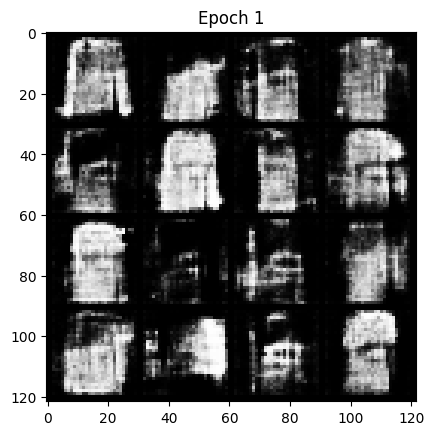

Epoch [2/10], Step [200/469], D Loss: 0.2767, G Loss: 2.4695
Epoch [2/10], Step [400/469], D Loss: 0.3771, G Loss: 2.8661


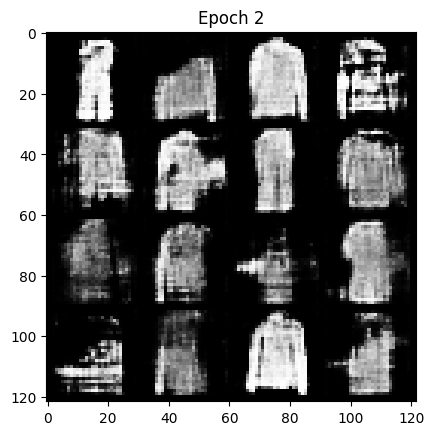

Epoch [3/10], Step [200/469], D Loss: 0.4882, G Loss: 1.5258
Epoch [3/10], Step [400/469], D Loss: 0.6242, G Loss: 2.2799


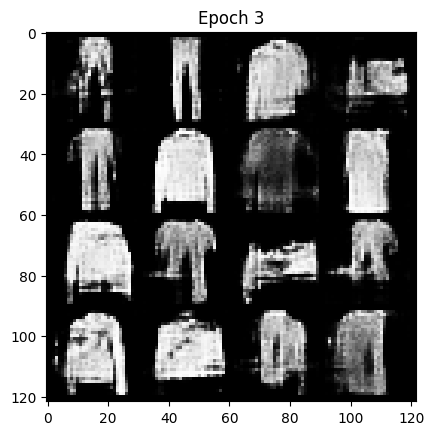

Epoch [4/10], Step [200/469], D Loss: 0.6260, G Loss: 2.2409
Epoch [4/10], Step [400/469], D Loss: 0.6100, G Loss: 1.1808


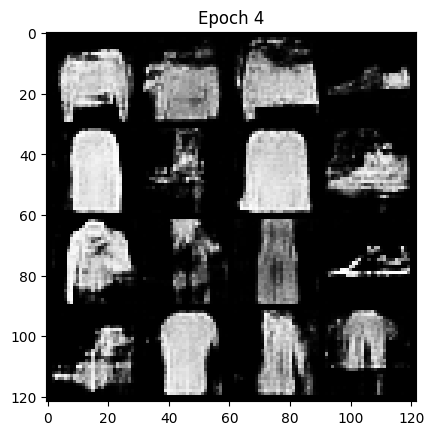

Epoch [5/10], Step [200/469], D Loss: 0.6627, G Loss: 1.5841
Epoch [5/10], Step [400/469], D Loss: 0.9133, G Loss: 2.4106


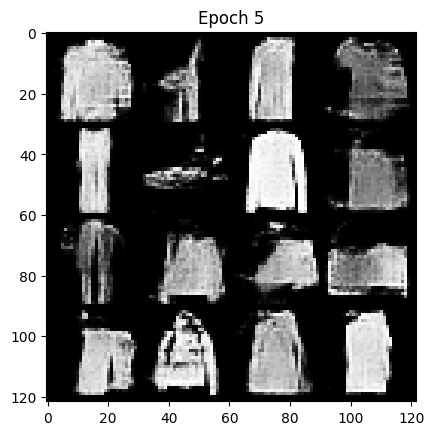

Epoch [6/10], Step [200/469], D Loss: 0.8501, G Loss: 2.3996
Epoch [6/10], Step [400/469], D Loss: 0.7851, G Loss: 1.5674


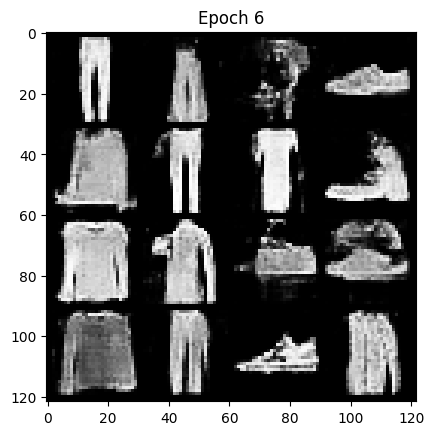

Epoch [7/10], Step [200/469], D Loss: 0.7667, G Loss: 2.7134
Epoch [7/10], Step [400/469], D Loss: 0.5822, G Loss: 1.6175


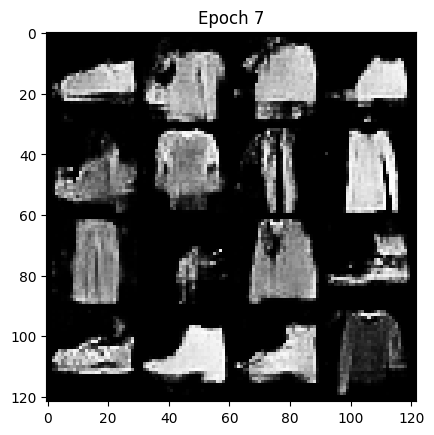

Epoch [8/10], Step [200/469], D Loss: 0.6071, G Loss: 2.0480
Epoch [8/10], Step [400/469], D Loss: 0.6723, G Loss: 2.1113


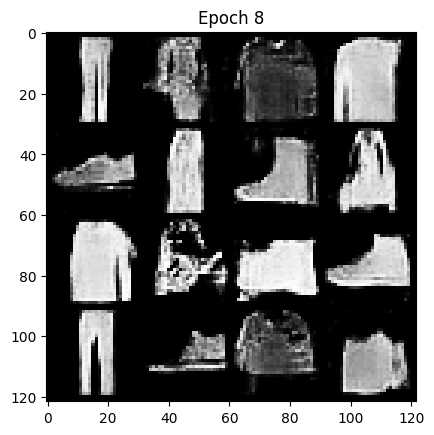

Epoch [9/10], Step [200/469], D Loss: 0.7621, G Loss: 1.5674
Epoch [9/10], Step [400/469], D Loss: 0.6840, G Loss: 1.5405


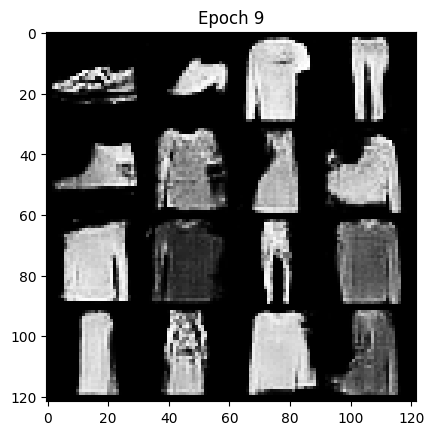

Epoch [10/10], Step [200/469], D Loss: 0.7997, G Loss: 1.3026
Epoch [10/10], Step [400/469], D Loss: 0.7810, G Loss: 1.2366


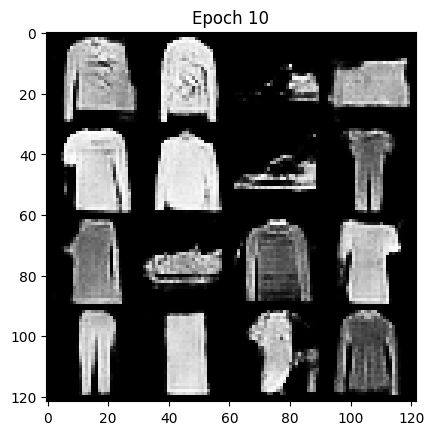

In [6]:
# 랜덤 시드 고정 (재현성을 위해)
torch.manual_seed(0)

# 하이퍼파라미터 설정
latent_dim = 100
batch_size = 128
epochs = 10
lr_G = 0.0001  # Generator 학습률 조정
lr_D = 0.0002  # Discriminator 학습률 조정
beta1 = 0.5

# GPU 사용 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 데이터 전처리 및 로드
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # [-1, 1] 범위로 정규화
])

fashion_mnist_data = datasets.FashionMNIST(root='./data', train=True, transform=transform, download=True)
data_loader = DataLoader(fashion_mnist_data, batch_size=batch_size, shuffle=True)

# Generator 정의 (ConvTranspose 사용)
class Generator(nn.Module):
    def __init__(self, latent_dim):
        super(Generator, self).__init__()
        self.model = nn.Sequential(
            nn.ConvTranspose2d(latent_dim, 128, kernel_size=7, stride=1, padding=0),
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            nn.ConvTranspose2d(64, 1, kernel_size=4, stride=2, padding=1),
            nn.Tanh()
        )

    def forward(self, z):
        z = z.view(z.size(0), -1, 1, 1)  # 입력 형태 맞추기
        return self.model(z)

# Discriminator 정의 (Conv 사용)
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Flatten(),
            nn.Linear(128 * 7 * 7, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

# 모델 초기화
generator = Generator(latent_dim).to(device)
discriminator = Discriminator().to(device)

# 손실 함수 및 최적화기 정의
criterion = nn.BCELoss()
optimizer_G = optim.Adam(generator.parameters(), lr=lr_G, betas=(beta1, 0.999))
optimizer_D = optim.Adam(discriminator.parameters(), lr=lr_D, betas=(beta1, 0.999))

# 학습 루프
for epoch in range(epochs):
    for i, (real_images, _) in enumerate(data_loader):
        real_images = real_images.to(device)
        batch_size = real_images.size(0)

        # 진짜와 가짜 레이블 생성
        real_labels = torch.ones(batch_size, 1).to(device)
        fake_labels = torch.zeros(batch_size, 1).to(device)

        # **1. Discriminator 학습**
        optimizer_D.zero_grad()

        # 진짜 이미지에 대한 손실
        outputs = discriminator(real_images)
        loss_real = criterion(outputs, real_labels)

        # 가짜 이미지에 대한 손실
        z = torch.randn(batch_size, latent_dim).to(device)
        fake_images = generator(z)
        outputs = discriminator(fake_images.detach())
        loss_fake = criterion(outputs, fake_labels)

        # Discriminator의 총 손실 및 역전파
        loss_D = loss_real + loss_fake
        loss_D.backward()
        optimizer_D.step()

        # **2. Generator 학습**
        optimizer_G.zero_grad()

        # Generator가 생성한 이미지를 판별자에 입력하여 손실 계산
        outputs = discriminator(fake_images)
        loss_G = criterion(outputs, real_labels)

        # 역전파 및 최적화
        loss_G.backward()
        optimizer_G.step()

        # 학습 과정 출력
        if (i + 1) % 200 == 0:
            print(f"Epoch [{epoch+1}/{epochs}], Step [{i+1}/{len(data_loader)}], "
                  f"D Loss: {loss_D.item():.4f}, G Loss: {loss_G.item():.4f}")

    # 생성된 이미지 샘플 출력
    with torch.no_grad():
        z = torch.randn(16, latent_dim).to(device)
        fake_images = generator(z)
        fake_images = (fake_images + 1) / 2  # Normalize to [0, 1]
        grid = np.transpose(torchvision.utils.make_grid(fake_images.cpu(), nrow=4, padding=2).numpy(), (1, 2, 0))
        plt.imshow(grid, cmap='gray')
        plt.title(f'Epoch {epoch+1}')
        plt.show()
